In [1]:
import pandas as pd
import numpy as np

from math import isnan
import multiprocessing as mp
import matplotlib.pyplot as plt
import json
from protocols import utils, functions, graphs
from matplotlib_venn import venn2
from functools import partial
from joblib import Memory
from multiprocessing import Pool, get_context

import gumpy


%load_ext autoreload
%autoreload 2

# Compare contents of WHOv1 vs catomatic (CRyPTIC 1), as trained on same data

In [2]:
def load_who_catalogue(path):
    #Prep data for comparisons:
    who = pd.read_csv(path)
    who['EVIDENCE'] = who['EVIDENCE'].apply(utils.str_to_dict)
    who['GENBANK_REFERENCE'] = 'NC00962.3'
    who['CATALOGUE_VERSION'] = 0
    who['CATALOGUE_NAME'] = '-'
    #filter out default rules
    who = who[~who['EVIDENCE'].apply(lambda x: isinstance(x, dict) and 'reporting_rule' in x)]
    return who

who = load_who_catalogue('catalogues/whov1/NC_000962.3_WHO-UCN-GTB-PCI-2021.7_v1.2_GARC1_RUS.csv')
who['solo_R'] = who['EVIDENCE'].apply(lambda x: utils.extract_value(x, 'Present_R'))
who['solo_S'] = who['EVIDENCE'].apply(lambda x: utils.extract_value(x, 'Present_S'))
who['TOTAL'] = who['solo_R'] + who['solo_S']
who['PROPORTION'] = who['solo_R']/(who['solo_R']+who['solo_S'])
who['CONFIDENCE'] = who.apply(utils.wilson_ci, R_col='solo_R', S_col='solo_S', axis=1)
u_who = who[~who.PREDICTION.isin(['R','S'])]
who = who[who.PREDICTION.isin(['R','S'])]

def load_catomatic_catalogues(opt_path, base_path):
    """Load and process catomatic catalogues from optimal parameter settings."""
    opt_df = pd.read_csv(opt_path)
    valid_drugs = opt_df

    # Load catalogue files based on optimal settings
    catalogue_dfs = valid_drugs.apply(
        lambda row: pd.read_csv(
            f"{base_path}/{row['DRUG'].lower()}/bg_{row['BACKGROUND_RATE']}_p_{row['p_value']}_FRS_0.1.csv"
        ),
        axis=1
    ).tolist()

    cat_df = pd.concat(catalogue_dfs)
    cat_df['CATALOGUE_VERSION'] = 0
    cat_df['CATALOGUE_NAME'] = '-'

    # Parse evidence
    cat_df['EVIDENCE'] = cat_df['EVIDENCE'].apply(utils.str_to_dict)
    cat_df = cat_df[~cat_df['EVIDENCE'].apply(lambda x: isinstance(x, dict) and 'default_rule' in x)]

    # Extract key metrics
    cat_df['solo_R'] = cat_df['EVIDENCE'].apply(lambda x: utils.extract_value(x, 'contingency', 0, 0))
    cat_df['solo_S'] = cat_df['EVIDENCE'].apply(lambda x: utils.extract_value(x, 'contingency', 0, 1))
    cat_df['TOTAL'] = cat_df['solo_R'] + cat_df['solo_S']
    cat_df['PROPORTION'] = cat_df['EVIDENCE'].apply(lambda x: utils.extract_value(x, 'proportion'))
    cat_df['CONFIDENCE'] = cat_df['EVIDENCE'].apply(lambda x: utils.extract_value(x, 'confidence'))

    # Keep only R and S predictions
    unknown = cat_df[~cat_df.PREDICTION.isin(['R', 'S'])]
    cat_df = cat_df[cat_df.PREDICTION.isin(['R', 'S'])]

    return cat_df, unknown

# Load both catalogue sets
cat, u_cat = load_catomatic_catalogues(
    'results/grid_search/opt_cats_MTBC-CRyPTICv1.1.1-2025.8.csv',
    './catalogues/MTBC-CRyPTICv1.1.1-2025.8/grid_search'
)

valid_drugs = cat.DRUG.unique()

/Users/dylanadlard/Documents/Oxford/PhD/Projects/cryptic-catalogues-2025/protocols/utils.py:596: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered['PREDICTION'] = filtered['INITIAL CONFIDENCE GRADING'].map(prediction_map)
/Users/dylanadlard/Documents/Oxford/PhD/Projects/cryptic-catalogues-2025/protocols/utils.py:606: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cat2_no_rules['PREDICTION'] = cat2_no_rules.apply(


RIF


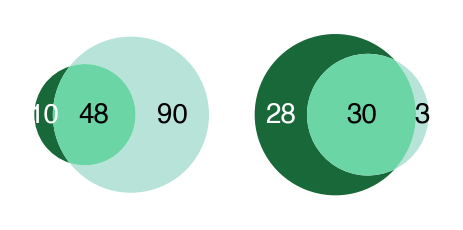

INH


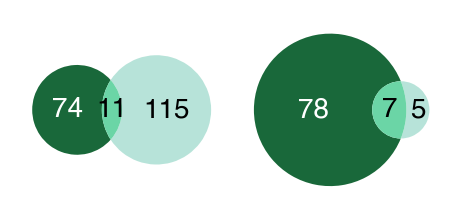

STM


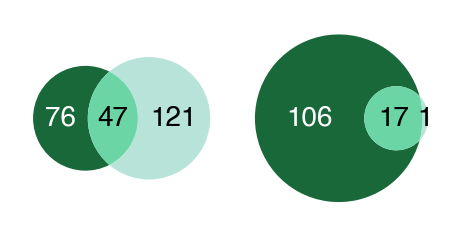

LEV


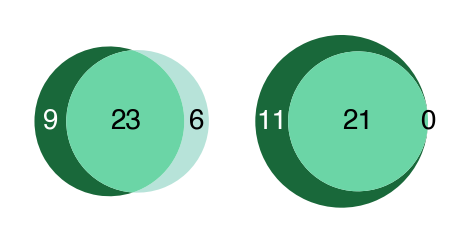

MXF


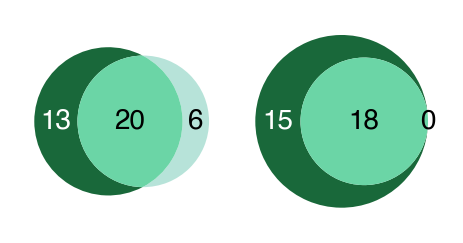

EMB


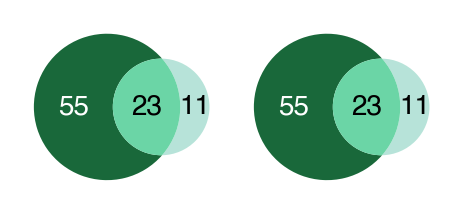

PZA


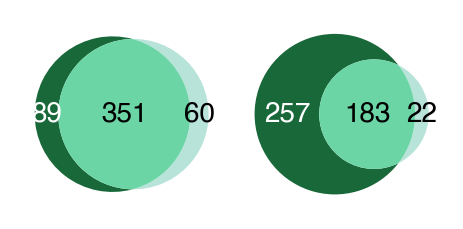

AMI


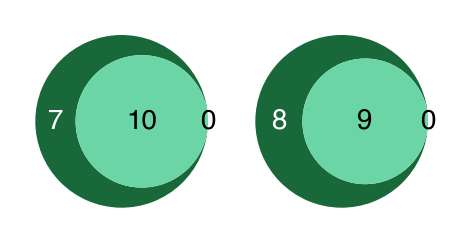

CAP


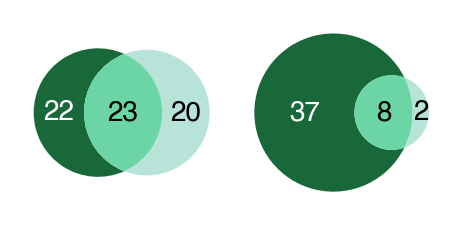

ETH


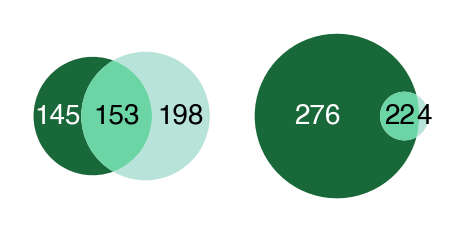

KAN


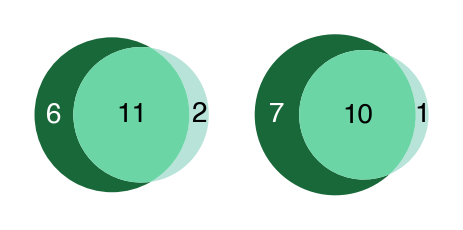

BDQ


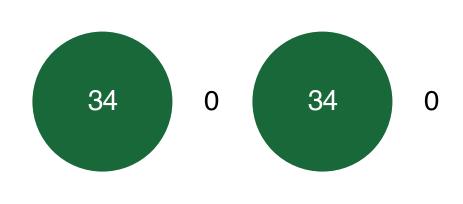

CIP


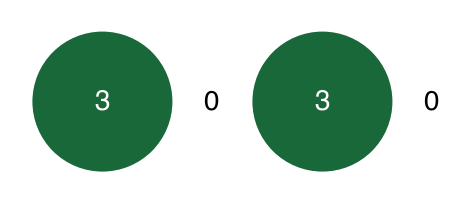

LZD


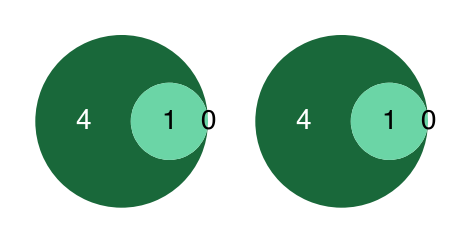

DLM


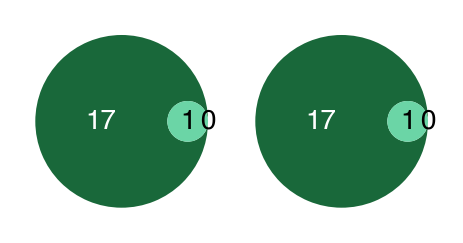

CFZ


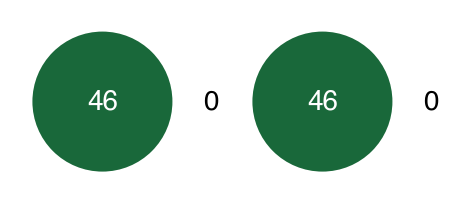

In [3]:
expanded_catalogues = utils.expand_catalogue_pair(cat, who, valid_drugs, 'RUS', ('cat', 'who'), who_cat='WHOv1')

catalogue_palette = {
    "catomatic_v1": "#70c0b3", 
    "catomatic_v3": "#018571",  
    "WHOv1": "#d5b477",        
    "WHOv2": "#a6611a",        
}


# Plot diagrams with and without rules
graphs.plot_venn_pair_per_drug(expanded_catalogues, valid_drugs,  'figs/discordance/')


## Summary table including rules

In [4]:
all_drugs_merged = pd.concat(expanded_catalogues[drug]['merged'] for drug in valid_drugs)
suffixes = ('cat', 'who')
all_drugs_merged['PREDICTION_PAIR'] = all_drugs_merged.apply(utils.classify_predictions, axis=1, args=(suffixes,))
all_drugs_merged['DRUG'] = all_drugs_merged['DRUG_who'].combine_first(all_drugs_merged['DRUG_cat'])

summary_table = (
    all_drugs_merged.drop_duplicates(['DRUG', 'MUTATION']).groupby(['DRUG', 'PREDICTION_PAIR'])
    .size()
    .unstack(fill_value=0)  # Pivot table to create columns for prediction pairs
    .reset_index()  # Resets the index, moving 'PREDICTION_PAIR' into a column
)

summary_table.rename(columns={'DRUG': 'DRUG'}, inplace=True)
summary_table['total'] = summary_table.drop(columns=['DRUG']).sum(axis=1)
summary_table.columns.name = None

print ('Prediction pairs comparing catomatic_v1 with WHOv1, including rules:')
summary_table

Prediction pairs comparing catomatic_v1 with WHOv1, including rules:


,DRUG,R.R,R.S,R.U,S.R,S.S,S.U,U.R,U.S,total
0,AMI,4,0,7,0,6,0,0,0,17
1,BDQ,0,0,34,0,0,0,0,0,34
2,CAP,21,0,22,0,2,0,18,2,65
3,CFZ,0,0,46,0,0,0,0,0,46
4,CIP,0,0,2,0,0,1,0,0,3
5,DLM,1,0,17,0,0,0,0,0,18
6,EMB,12,0,8,0,11,47,3,8,89
7,ETH,153,0,145,0,0,0,198,0,496
8,INH,10,0,52,0,1,22,112,3,200
9,KAN,8,0,3,0,3,3,0,2,19


In [5]:
def nan_friendly_filter(series, value):
    if pd.isna(value):
        return series.isna()
    else:
        return series == value

# Example usage:
drug = "STM"
cat_pheno = 'R'
who_pheno = np.nan
#np.nan

all_drugs_merged[
    (all_drugs_merged.DRUG==drug) &
    nan_friendly_filter(all_drugs_merged.PREDICTION_who, who_pheno) &
    nan_friendly_filter(all_drugs_merged.PREDICTION_cat, cat_pheno)
]

,Unnamed: 0_cat,GENBANK_REFERENCE_cat,CATALOGUE_NAME_cat,CATALOGUE_VERSION_cat,CATALOGUE_GRAMMAR_cat,PREDICTION_VALUES_cat,DRUG_cat,MUTATION,PREDICTION_cat,SOURCE_cat,...,EVIDENCE_who,OTHER_who,Unnamed: 0_who,solo_R_who,solo_S_who,TOTAL_who,PROPORTION_who,CONFIDENCE_who,PREDICTION_PAIR,DRUG
0,266.0,NC00962.3,-,0.0,GARC1,RUS,STM,gid@-33_del_t,R,{},...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,R.U,STM
146,188.0,NC00962.3,-,0.0,GARC1,RUS,STM,gid@A119D,R,{},...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,R.U,STM
147,300.0,NC00962.3,-,0.0,GARC1,RUS,STM,gid@A133P,R,{},...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,R.U,STM
149,275.0,NC00962.3,-,0.0,GARC1,RUS,STM,gid@A138E,R,{},...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,R.U,STM
150,128.0,NC00962.3,-,0.0,GARC1,RUS,STM,gid@A138P,R,{},...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,R.U,STM
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
266,137.0,NC00962.3,-,0.0,GARC1,RUS,STM,rrs@a514t,R,{},...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,R.U,STM
267,551.0,NC00962.3,-,0.0,GARC1,RUS,STM,rrs@a907c,R,{},...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,R.U,STM
268,191.0,NC00962.3,-,0.0,GARC1,RUS,STM,rrs@a907t,R,{},...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,R.U,STM
271,502.0,NC00962.3,-,0.0,GARC1,RUS,STM,rrs@c513t,R,{},...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,R.U,STM


## Summary table exlcuding rules

In [6]:
all_drugs_who = pd.concat(expanded_catalogues[drug]['who'] for drug in valid_drugs)
all_drugs_who = all_drugs_who[all_drugs_who.PREDICTION!='U']
all_drugs_cat = pd.concat(expanded_catalogues[drug]['cat'] for drug in valid_drugs)
all_drugs_cat = all_drugs_cat[all_drugs_cat.PREDICTION!='U']

suffixes = ('_cat', '_who')

all_drugs_merged = pd.merge(all_drugs_cat, all_drugs_who, on=['DRUG', 'MUTATION'], how='outer', suffixes=suffixes)
suffixes = ('cat', 'who')

all_drugs_merged['PREDICTION_PAIR'] = all_drugs_merged.apply(utils.classify_predictions, axis=1, args=(suffixes,))
all_drugs_merged = all_drugs_merged[all_drugs_merged.EVIDENCE_who!={'expanded_rule'}]

summary_table = (
    all_drugs_merged.drop_duplicates(['DRUG', 'MUTATION']).groupby(['DRUG', 'PREDICTION_PAIR'])
    .size()
    .unstack(fill_value=0)  # Pivot table to create columns for prediction pairs
    .reset_index()  # Resets the index, moving 'PREDICTION_PAIR' into a column
)

summary_table.rename(columns={'DRUG': 'DRUG'}, inplace=True)
summary_table['total'] = summary_table.drop(columns=['DRUG']).sum(axis=1)
summary_table.columns.name = None

print ('Prediction pairs comparing catomatic_v1 with WHOv1, excluding rules:')
summary_table

Prediction pairs comparing catomatic_v1 with WHOv1, excluding rules:


,DRUG,R.R,R.S,R.U,S.S,S.U,U.R,U.S,U.U,total
0,AMI,3,0,8,6,0,0,0,0,17
1,BDQ,0,0,34,0,0,0,0,0,34
2,CAP,6,0,36,2,0,0,2,0,46
3,CFZ,0,0,46,0,0,0,0,0,46
4,CIP,0,0,2,0,1,0,0,0,3
5,DLM,1,0,17,0,0,0,0,0,18
6,EMB,12,0,8,11,47,3,8,0,89
7,ETH,22,0,237,0,0,4,0,0,263
8,INH,6,0,56,1,22,2,3,0,90
9,KAN,7,0,4,3,3,0,1,0,18


In [7]:
def nan_friendly_filter(series, value):
    if pd.isna(value):
        return series.isna()
    else:
        return series == value

drug = "STM"
cat_pheno = 'S'
who_pheno = np.nan 
#np.nan

all_drugs_merged[
    (all_drugs_merged.DRUG == drug) &
    nan_friendly_filter(all_drugs_merged.PREDICTION_who, who_pheno) &
    nan_friendly_filter(all_drugs_merged.PREDICTION_cat, cat_pheno)
]

,Unnamed: 0_cat,GENBANK_REFERENCE_cat,CATALOGUE_NAME_cat,CATALOGUE_VERSION_cat,CATALOGUE_GRAMMAR_cat,PREDICTION_VALUES_cat,DRUG,MUTATION,PREDICTION_cat,SOURCE_cat,...,SOURCE_who,EVIDENCE_who,OTHER_who,Unnamed: 0_who,solo_R_who,solo_S_who,TOTAL_who,PROPORTION_who,CONFIDENCE_who,PREDICTION_PAIR
1289,3.0,NC00962.3,-,0.0,GARC1,RUS,STM,gid@A205T,S,{},...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,S.U
1364,2.0,NC00962.3,-,0.0,GARC1,RUS,STM,gid@c-11t,S,{},...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,S.U
1374,6.0,NC00962.3,-,0.0,GARC1,RUS,STM,rrs@c1443g,S,{},...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,S.U
1380,4.0,NC00962.3,-,0.0,GARC1,RUS,STM,rrs@t-4g,S,{},...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,S.U


# Compare catomatic on training set vs catomatic on entire dataset

In [8]:
# Load both catalogue sets
cat, u_cat = load_catomatic_catalogues(
    'results/grid_search/opt_cats_MTBC-CRyPTICv1.1.1-2025.8.csv',
    './catalogues/MTBC-CRyPTICv1.1.1-2025.8/grid_search'
)

cats_all, u_cats_all = load_catomatic_catalogues(
    'results/grid_search/opt_cats_MTBC-CRyPTICv1.1.1-2025.8.csv', 
    './catalogues/MTBC-CRyPTICv3.4.0-2025.8/grid_search'
)

RIF


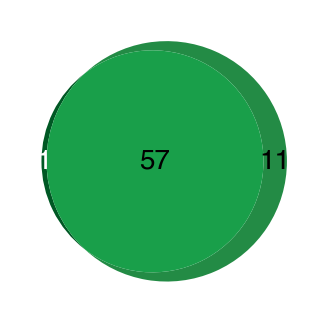

INH


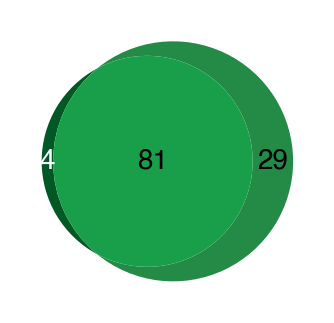

STM


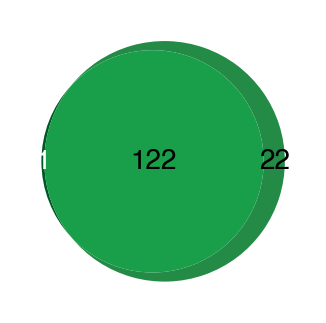

LEV


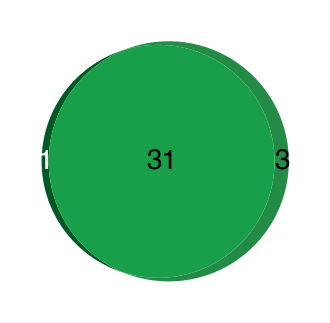

MXF


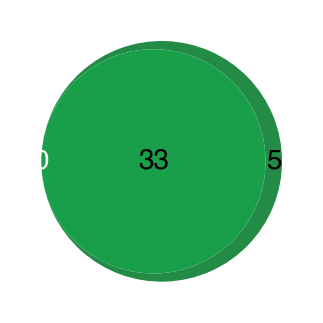

EMB


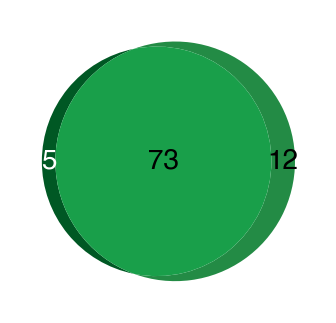

PZA


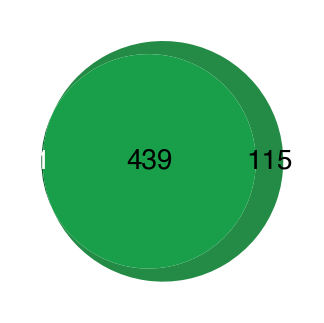

AMI


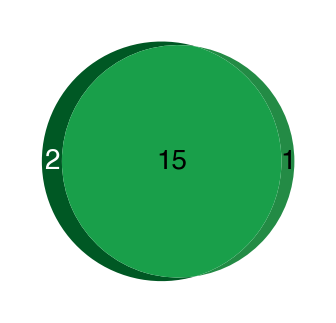

CAP


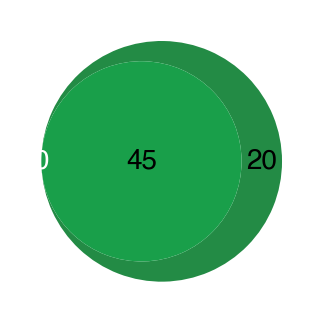

ETH


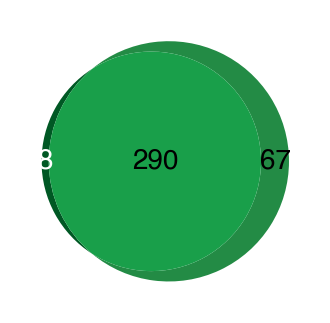

KAN


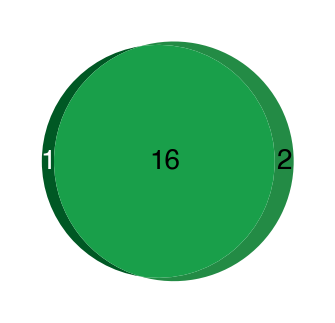

BDQ


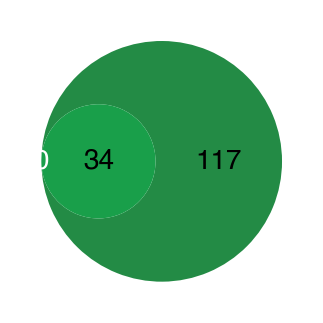

CIP


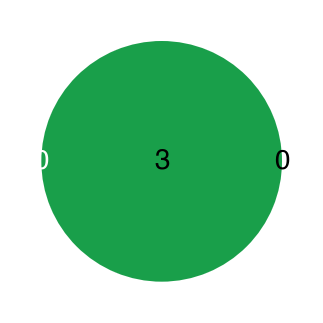

LZD


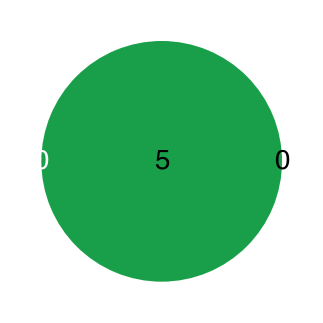

DLM


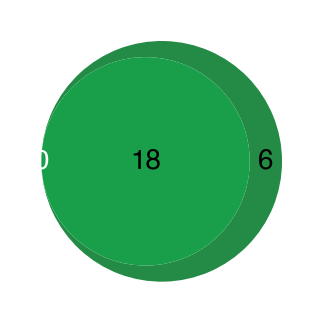

CFZ


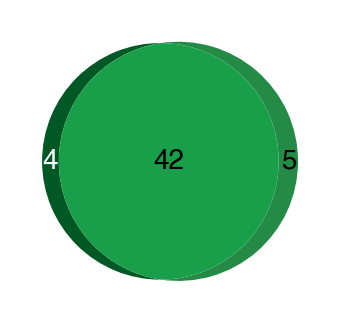

In [9]:
expanded_catalogues = utils.expand_catalogue_pair(cat, cats_all, valid_drugs, 'RUS', ('cat', 'cat_all'), who_cat=None)
# Plot diagrams with and without rules
graphs.plot_venn_catomatic_per_drug(expanded_catalogues, valid_drugs,  'figs/discordance/')


In [10]:
print ('number of rows more in catalogue trained on all data:', len(cats_all)-len(cat))

number of rows more in catalogue trained on all data: 387


### Summary table including rules

In [11]:
all_drugs_merged = pd.concat(expanded_catalogues[drug]['merged'] for drug in valid_drugs)
suffixes = ('cat', 'cat_all')
all_drugs_merged['PREDICTION_PAIR'] = all_drugs_merged.apply(utils.classify_predictions, axis=1, args=(suffixes,))
all_drugs_merged['DRUG'] = all_drugs_merged['DRUG_cat_all'].combine_first(all_drugs_merged['DRUG_cat'])

summary_table = (
    all_drugs_merged.drop_duplicates(['DRUG', 'MUTATION']).groupby(['DRUG', 'PREDICTION_PAIR'])
    .size()
    .unstack(fill_value=0)  # Pivot table to create columns for prediction pairs
    .reset_index()  # Resets the index, moving 'PREDICTION_PAIR' into a column
)

summary_table.rename(columns={'DRUG': 'DRUG'}, inplace=True)
summary_table['total'] = summary_table.drop(columns=['DRUG']).sum(axis=1)
summary_table.columns.name = None

print ('Prediction pairs comparing catomatic_v1 with catoamtic trained on all samples , including rules:')
summary_table

Prediction pairs comparing catomatic_v1 with catoamtic trained on all samples , including rules:


,DRUG,R.R,R.U,S.R,S.S,U.R,U.S,total
0,AMI,9,2,0,6,1,0,18
1,BDQ,34,0,0,0,117,0,151
2,CAP,43,0,0,2,20,0,65
3,CFZ,42,4,0,0,5,0,51
4,CIP,2,0,0,1,0,0,3
5,DLM,18,0,0,0,5,1,24
6,EMB,15,5,1,57,3,9,90
7,ETH,290,8,0,0,67,0,365
8,INH,58,4,0,23,25,4,114
9,KAN,10,1,0,6,1,1,19


In [12]:
def nan_friendly_filter(series, value):
    if pd.isna(value):
        return series.isna()
    else:
        return series == value

# Example usage:
drug = "KAN"
cat_pheno = 'R'
who_pheno = np.nan
#np.nan

changes = all_drugs_merged[
    (all_drugs_merged.DRUG==drug) &
    nan_friendly_filter(all_drugs_merged.PREDICTION_cat_all, who_pheno) &
    nan_friendly_filter(all_drugs_merged.PREDICTION_cat, cat_pheno)
].MUTATION.values

full_cat_all = pd.concat([cats_all, u_cats_all])
full_cat_all[(full_cat_all.DRUG==drug)&full_cat_all.MUTATION.isin(changes)]

,Unnamed: 0,GENBANK_REFERENCE,CATALOGUE_NAME,CATALOGUE_VERSION,CATALOGUE_GRAMMAR,PREDICTION_VALUES,DRUG,MUTATION,PREDICTION,SOURCE,EVIDENCE,OTHER,solo_R,solo_S,TOTAL,PROPORTION,CONFIDENCE
89,83,NC00962.3,-,0,GARC1,RUS,KAN,eis@c-8t,U,{},"{'proportion': 0.2857142857142857, 'confidence...",{},2.0,5.0,7.0,0.285714,"[0.09956584356228707, 0.5913324544888023]"


In [13]:
all_drugs_merged

,Unnamed: 0_cat,GENBANK_REFERENCE_cat,CATALOGUE_NAME_cat,CATALOGUE_VERSION_cat,CATALOGUE_GRAMMAR_cat,PREDICTION_VALUES_cat,DRUG_cat,MUTATION,PREDICTION_cat,SOURCE_cat,...,SOURCE_cat_all,EVIDENCE_cat_all,OTHER_cat_all,solo_R_cat_all,solo_S_cat_all,TOTAL_cat_all,PROPORTION_cat_all,CONFIDENCE_cat_all,PREDICTION_PAIR,DRUG
0,35.0,NC00962.3,-,0.0,GARC1,RUS,RIF,rpoB@1263_del_caaggagttcttcggcac,R,{},...,{},"{'proportion': 1.0, 'confidence': [0.425030609...",{},2.0,0.0,2.0,1.000000,"[0.4250306090063464, 1.0]",R.R,RIF
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,rpoB@1277_del_gcacca,NaN,NaN,...,{},"{'proportion': 0.75, 'confidence': [0.35616800...",{},3.0,1.0,4.0,0.750000,"[0.3561680085985064, 0.9420926788001412]",U.R,RIF
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,rpoB@1282_del_agccagctg,NaN,NaN,...,{},"{'proportion': 1.0, 'confidence': [0.425030609...",{},2.0,0.0,2.0,1.000000,"[0.4250306090063464, 1.0]",U.R,RIF
3,101.0,NC00962.3,-,0.0,GARC1,RUS,RIF,rpoB@1292_ins_cca,R,{},...,{},"{'proportion': 1.0, 'confidence': [0.648883499...",{},5.0,0.0,5.0,1.000000,"[0.6488834992348989, 1.0]",R.R,RIF
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,rpoB@1293_del_ccaatt,NaN,NaN,...,{},"{'proportion': 1.0, 'confidence': [0.596521374...",{},4.0,0.0,4.0,1.000000,"[0.5965213747972954, 1.0]",U.R,RIF
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46,187.0,NC00962.3,-,0.0,GARC1,RUS,CFZ,pepQ@298_ins_c,R,{},...,{},"{'proportion': 1.0, 'confidence': [0.269865948...",{},1.0,0.0,1.0,1.000000,"[0.26986594878405434, 1.0000000000000002]",R.R,CFZ
47,179.0,NC00962.3,-,0.0,GARC1,RUS,CFZ,pepQ@693_ins_a,R,{},...,{},"{'proportion': 1.0, 'confidence': [0.269865948...",{},1.0,0.0,1.0,1.000000,"[0.26986594878405434, 1.0000000000000002]",R.R,CFZ
48,176.0,NC00962.3,-,0.0,GARC1,RUS,CFZ,pepQ@817_ins_g,R,{},...,{},"{'proportion': 0.5, 'confidence': [0.120866319...",{},1.0,1.0,2.0,0.500000,"[0.12086631942227369, 0.8791336805777263]",R.R,CFZ
49,116.0,NC00962.3,-,0.0,GARC1,RUS,CFZ,pepQ@G197R,R,{},...,{},"{'proportion': 0.13157894736842105, 'confidenc...",{},5.0,33.0,38.0,0.131579,"[0.06554322112779692, 0.2465897803250334]",R.R,CFZ
